# Mean-baseline audit and channel-count feasibility

**Both channel-count candidates are rejected.** At M32, seven actual p90 covariance/precision means classify 90.6%; holding total coupling fixed weakens focused z to 51.6%. The factor classes are also exactly related by channel sign changes and relabeling, limiting their value as a dependence-character example. The aim remains weak raw **p90 MPI means** with a reliable SPI–SPI signal. This notebook first audits existing p90 banks with stronger mean readouts, then tests a channel-count hypothesis using a small custom probe catalogue. The new M32 results below are **not p90 results**. Signed distribution summaries remain informative.

In [1]:
from pathlib import Path
import pandas as pd,json
from IPython.display import display,Image
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
OUT=ROOT/'results/representation/factor-channel-scout-261004'
for run in ['lag-surrogate-261004','factor-parity-replication-261004']:
    print(run)
    folder=ROOT/'results/representation'/run/'development/marginal-audit'
    display(pd.read_csv(folder/'metrics.csv').round(4))
    display(pd.read_csv(folder/'selected-features.csv').round(4))

lag-surrogate-261004


,method,BA,selected_C,nonzero
0,mean_selected_linear,0.9375,NaN,NaN
1,mean_selected_stump,0.9062,NaN,NaN
2,distribution_selected_linear,0.9375,NaN,NaN
3,distribution_selected_stump,0.9688,NaN,NaN
4,mean_sparse_cv,1.0000,1.0,4.0


,method,feature,training_effect,validation_auc
0,mean,corr_kendall_tau-5-sq,-1.4515,0.9766
1,distribution,dtw/sd,-1.7501,0.9961


factor-parity-replication-261004


,method,BA,selected_C,nonzero
0,mean_selected_linear,0.4688,NaN,NaN
1,mean_selected_stump,0.4531,NaN,NaN
2,distribution_selected_linear,0.6875,NaN,NaN
3,distribution_selected_stump,0.6406,NaN,NaN
4,mean_sparse_cv,0.4375,1.0,79.0


,method,feature,training_effect,validation_auc
0,mean,cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5,-0.3514,0.5225
1,distribution,prec_OAS/q50,-0.7870,0.7773


The audit is exploratory reuse of already-seen development data; no held bank is opened. Single means are ranked using training standardized class differences, then fitted using training only. Sparse L1 logistic chooses C from .01/.1/1/10 by four grouped folds inside training; feature filtering, imputation and scaling are refitted in each fold, and both classes from a simulation block stay together. The surrogate mean vector reaches 100% with this sparse readout, resolving the apparent original weakness. The Gaussian-factor p90 mean controls remain near chance; that motivates a targeted channel-count scout rather than another covariance-only construction.

## What changes, and what is matched

The covariance is $C=(1-\lambda)I+\lambda\sum_{k=1}^3w_kv_kv_k^\top$, with unchanged $\lambda=.25$ and weights $(.9,.075,.025)$. Walsh columns $\{1,2,3\}$ give linked signs and $\{1,2,4\}$ unlinked signs. Both classes have the same population absolute covariance multiset, eigenvalues, row absolute totals and mean signed covariance at each M. They are temporally iid Gaussian models: the contrast is sign–magnitude organization, not nonlinear dynamics or causal coupling.

Fresh development seed 261022 generates 128 paired blocks, with 96 for training and 32 for validation. Each class/block has a 32-channel parent; the M8/16/32 views are nested and are not independent experiments. T stays 1000. Increasing M provides more channels and channel-pair observations; it does not make all edges independent. Per-edge population strength remains comparable, but total row coupling changes with M. The scout uses covariance, Pearson, squared Pearson, Spearman, squared Spearman, Euclidean distance, Gaussian plug-in MI, precision, squared precision and a maximum cross-correlation mean. Focused z uses the first nine matrices. These probes are not a replacement for p90.

The signed covariance distributions differ by construction. Consequently, success against means would not demonstrate that every per-SPI distribution is information-free. This is a substantive scope distinction, but these particular candidates fail even the mean-only target.

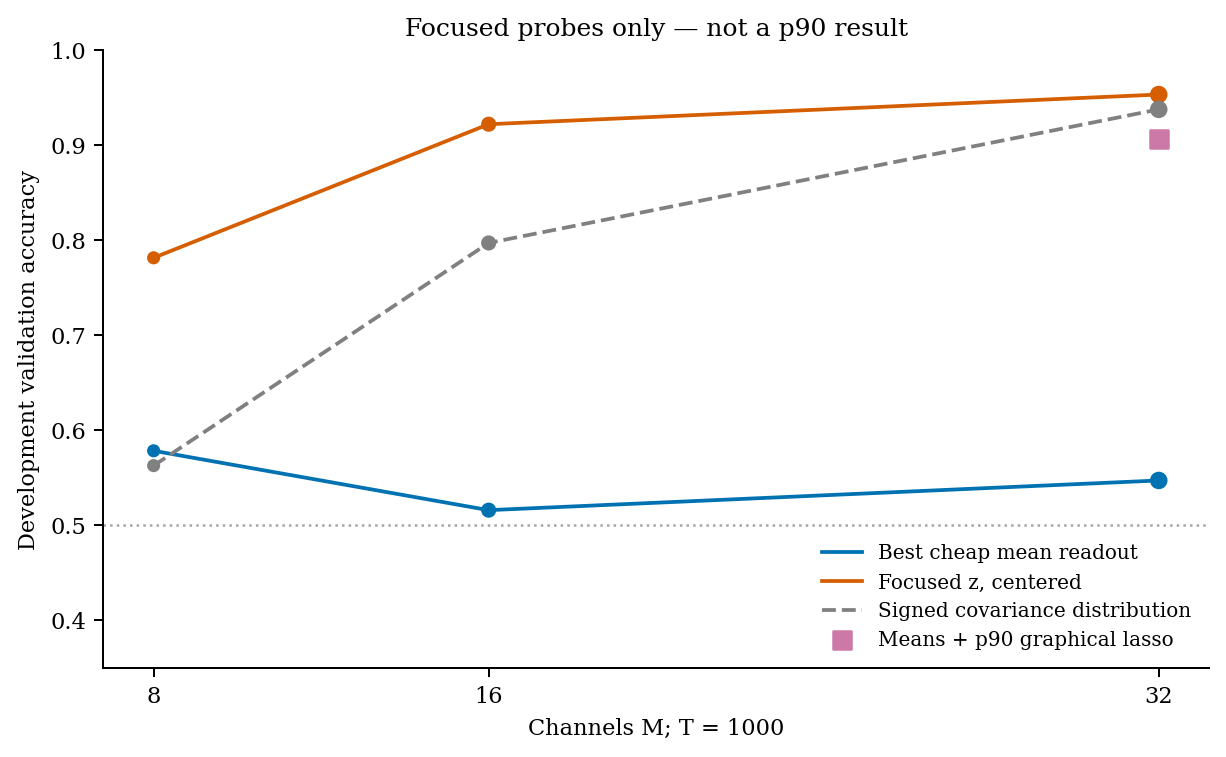

M,8,16,32
method,,,
Pearson_distribution,0.6562,0.7344,0.8750
covariance_distribution,0.5625,0.7969,0.9375
mean_RBF,0.5312,0.4688,0.5156
mean_full,0.5312,0.5156,0.4219
mean_selected_linear,0.5781,0.3906,0.5469
mean_selected_stump,0.4844,0.3906,0.5312
mean_trees,0.4844,0.4375,0.4219
z_center,0.7812,0.9219,0.9531
z_standard,0.7656,0.8594,0.9688


,method,BA
0,augmented_mean_linear,0.9375
1,augmented_mean_RBF,0.9219
2,augmented_mean_trees,0.8750
3,augmented_selected_linear,0.7656
4,augmented_selected_stump,0.7344


,method,BA
0,mean_linear,0.9062
1,mean_RBF,0.8594
2,mean_trees,0.7188


{'scope': 'Seven actual p90 means: empirical covariance/precision/precision squared and four GraphicalLasso covariance/precision means; same train/validation',
 'default_accuracy': 0.90625,
 'tight_tolerance_accuracy': 0.90625,
 'tight_convergence_warnings': 1,
 'tolerance': 'tol=enet_tol=1e-6,max_iter1000; sensitivity only, no p90 setting changes',
 'max_feature_change': 8.04198555123814e-07}

In [2]:
display(Image(filename=str(OUT/'figures/channel-scout.png')))
display(pd.read_csv(OUT/'metrics.csv').pivot(index='method',columns='M',values='BA').round(4))
display(pd.read_csv(OUT/'regularized-metrics.csv').round(4))
display(pd.read_csv(OUT/'graphical-default-metrics.csv').round(4))
display(json.loads((OUT/'graphical-tolerance-sensitivity.json').read_text()))

The additional M32 check includes covariance/precision means and squared means under graphical lasso at alpha .01/.1, addressing a known leakage route. The screening scores are 93.8% at best. Restricting to seven actual p90 means (empirical covariance, empirical precision and its square, plus four GraphicalLasso covariance/precision means at the actual default alpha .01) still gives 90.6%. Tightening solver tolerances leaves this accuracy unchanged. Default solves produce four convergence warnings across 256 fits; all outputs are finite, precision log determinants agree with independent Cholesky calculations, and the maximum inverse residual is 5.9e-5. Warnings and tolerance sensitivity are retained; no p90 settings were changed. No Gadi job is justified for this candidate.

## One principled scaling follow-up

The first scout holds per-edge strength fixed, so total absolute coupling per channel grows with M. The additional prespecified check holds the M16 total $g=.25(.9\times16-1)=3.35$ fixed, using $\lambda=g/(.9M-1)=.1205036$ at M32. Fresh development seed 261023 and the same training/validation sizes are used. Mean controls are now 43.8–60.9%, but centered focused z is 51.6% and standardized z 57.8%. The mean weakness comes with loss of the desired z signal. This branch stops; no parameter sweep or p90 submission follows.

In [3]:
display(pd.read_csv(ROOT/'results/representation/factor-total-strength-scout-261004/metrics.csv').round(4))

,method,BA
0,mean_linear,0.6094
1,mean_RBF,0.4844
2,mean_trees,0.5156
3,mean_selected_linear,0.5156
4,mean_selected_stump,0.4375
5,z_center,0.5156
6,z_standard,0.5781
7,covariance_distribution,0.5469
8,Pearson_distribution,0.5312


## More fundamental interpretation check

Writing the sign vectors as rows of $V$, a channel permutation $P$ and diagonal sign matrix $D$ satisfy $V_B=V_APD$. Therefore

$$C_B=D P^\top C_A P D.$$

The certificate below verifies this exactly at M8,16,32. Since the processes are Gaussian iid, their laws are related by the same signed channel transformation. Thus separation can reveal coordinate polarity sensitivity; it does not establish a different intrinsic Gaussian dynamical mechanism. Signs can have scientific meaning under a fixed measurement convention, but no such domain interpretation was established here. This makes the factor family a poor flagship example for the stated motivation, independently of the classifier failures. No held banks were opened in this follow-up, and no new p90 jobs were launched.

In [4]:
proof=json.loads((OUT/'polarity-equivalence.json').read_text()); display(proof['identity']); display(pd.DataFrame(proof['records'])[['M','max_covariance_error']])
display(json.loads((OUT/'protocol.json').read_text()))
display(json.loads((OUT/'regularized-validity.json').read_text()))

'V_B = V_A P D, hence C_B = D P^T C_A P D for any common diagonal factor weights and strength'

,M,max_covariance_error
0,8,0.0
1,16,0.0
2,32,0.0


{'status': 'Prospective local development-only scout; no held data or p90 jobs',
 'seed': 261022,
 'T': 1000,
 'M': [8, 16, 32],
 'training_blocks': [0, 95],
 'validation_blocks': [96, 127],
 'model': 'Unchanged lambda .25 and weights .9/.075/.025, Walsh linked/unlinked signs. Generate max32 Gaussian latent-factor parents; firstM channels are nested views, then apply label-independent channel permutation. Both classes share population absolute covariance multisets, eigenvalues and signed means within each M.',
 'source_sha256': 'b6d326d0ef1317754cd30a1f4f58d6eefaca93d89e256084bd7922c8286bf82a',
 'probe_source_sha256': '8d277de0376cf9270fc1fd575ac3e429096cf021644d59d35b3aa70a65f4d22b',
 'methods': 'Ten cheap MPI means; full linear/RBF/ExtraTrees; one training-ranked mean logistic/stump; probe z standardized/centered PCA20 logistic; covariance/Pearson distribution summaries secondary.',
 'criterion': 'Consider M32 p90 only if all cheap mean readouts<=.65 and focused z>=.85 at M32. This i

{'warnings': 17731, 'all_finite': True, 'selected_column': 16}